# Aprendizaje por imitación y DAGGER

Video que muestra cómo utilizan el "imitation learning" en Tesla:
https://youtu.be/v5l-jPsAK7k

In [1]:
from IPython.display import HTML

video_id = "v5l-jPsAK7k"
HTML(f"""
<iframe
    width="600"
    height="360"
    src="https://www.youtube-nocookie.com/embed/{video_id}"
    title="YouTube video player"
    frameborder="0"
    allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share"
    referrerpolicy="strict-origin-when-cross-origin"
    allowfullscreen>
</iframe>
""")

In [2]:
!pip install -q "gymnasium[atari]"
!pip install imageio==2.4.1
!pip install -q shimmy
!pip install -q moviepy==1.0.3

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 104.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for imageio: filename=imageio-2.4.1-py3-none-any.whl size=3303884 sha256=d599f834795c09a0d34d008235cb6ad344d0b786de0ccc56fc02fa0868210628
  Stored in directory: /root/.cache/pip/wheels/80/b9/62/b4ea29811d14efa100f4c104d87f6df91704f7a202d5df7dba
Successfully built imageio
  Attempting uninstall: imageio
    Found existing installation: ImageIO 2.37.3
    Uninstalling ImageIO-2.37.3:
      Successfully uninstalled ImageIO-2.37.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scikit-image 0.25.2 requires imageio!=2.35.0,>=2.33, but you have imageio 2.4.1 which is incompatible.
moviepy 1.0.3 requires imageio<3.0,>=2.5; python_version >= "3.4", but you have imageio 2.4.1 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from gymnasium.wrappers import TimeLimit
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import cv2
import os
import collections
from collections import deque
import matplotlib.pyplot as plt
from IPython.display import HTML, display
import ale_py

In [4]:
# para mejorar la reproducibilidad
torch.manual_seed(0)
np.random.seed(0)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [5]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
print(f"Versión de Gymnasium: {gym.__version__}")
print(f"Device: {DEVICE}")

Versión de Gymnasium: 1.3.0
Device: cuda


# Aprendizaje por imitación y DAGGER (Dataset Aggregation DAGGER)

**Problema:**

<img src="https://miro.medium.com/max/1400/1*P076bt-xcC3mKyYCINzSFg.jpeg">

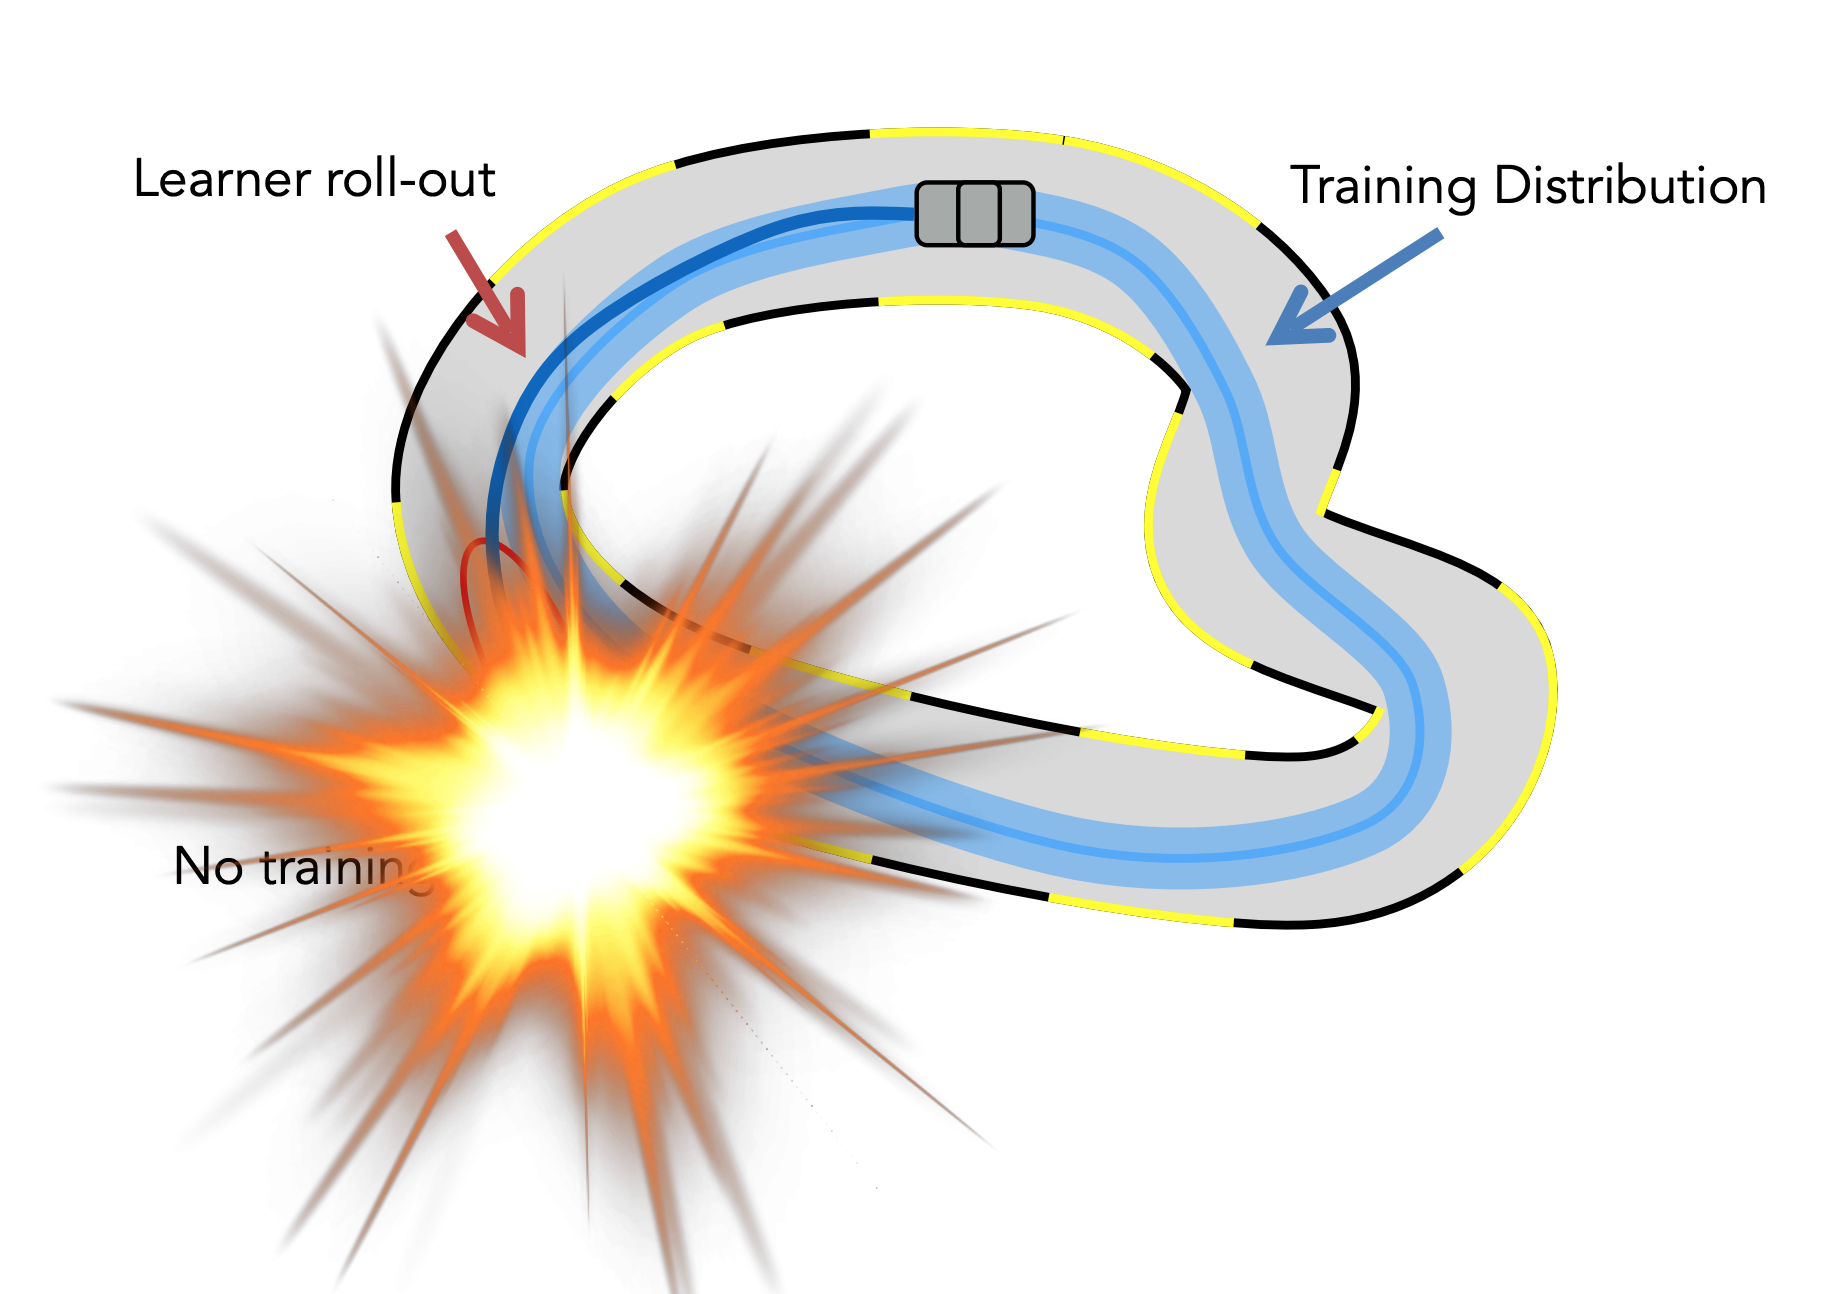


[Fuente](https://www.cc.gatech.edu/~bboots3/ACRL-Spring2019/Lectures/DAgger_slides.pdf)

# Ambiente

In [7]:
video_id = "yQW6TYltcSw"
HTML(f"""
<iframe
    width="600"
    height="360"
    src="https://www.youtube-nocookie.com/embed/{video_id}"
    title="YouTube video player"
    frameborder="0"
    allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share"
    referrerpolicy="strict-origin-when-cross-origin"
    allowfullscreen>
</iframe>
""")


## Preprocesamiento

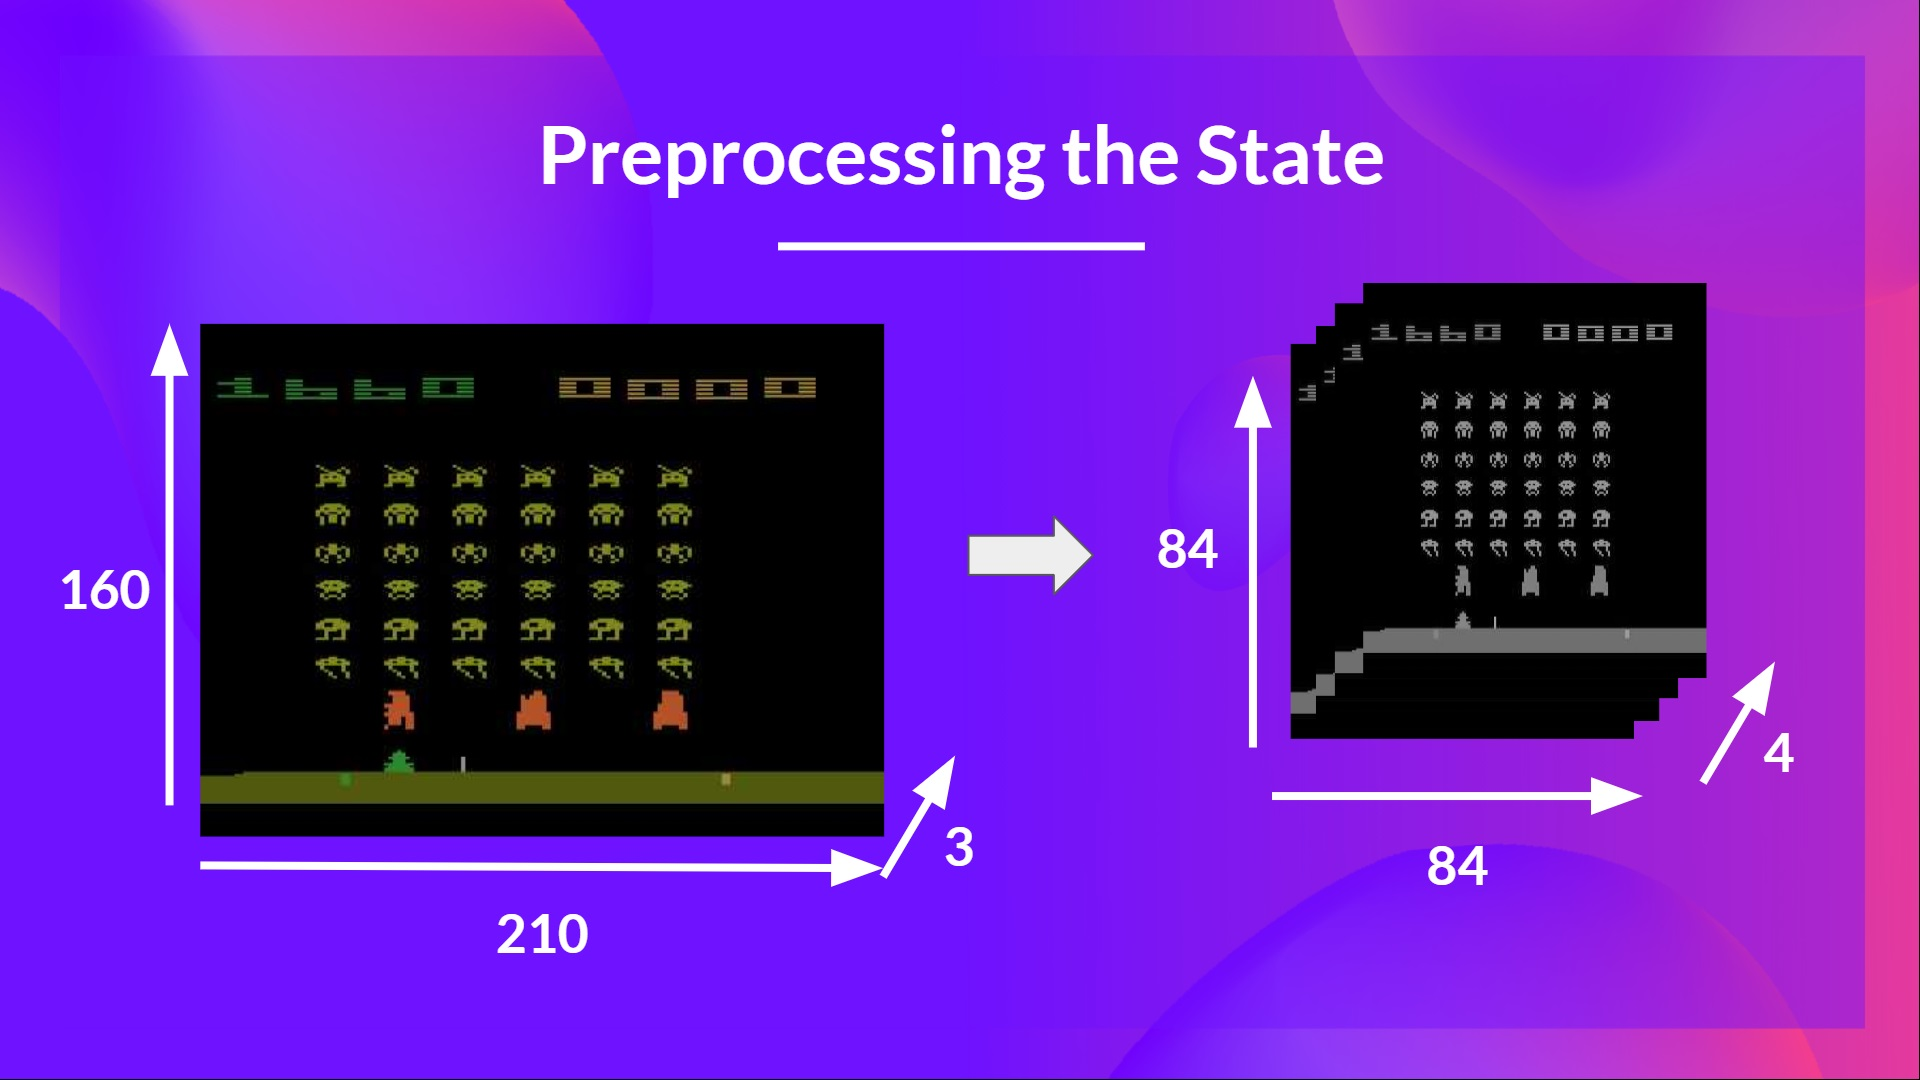

In [8]:
# Preprocesamiento basado en https://github.com/openai/baselines/blob/master/baselines/common/atari_wrappers.py

class NoopResetEnv(gym.Wrapper):
    def __init__(self, env, noop_max=30):
        super().__init__(env)
        self.noop_max = noop_max
        self.override_num_noops = None
        self.noop_action = 0 # Gymnasium v1.0+ ALE/Breakout-v5 mapea NOOP a 0

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        if self.override_num_noops is not None:
            noops = self.override_num_noops
        else:
            noops = np.random.randint(1, self.noop_max + 1)

        assert noops > 0
        for _ in range(noops):
            obs, _, terminated, truncated, info = self.env.step(self.noop_action)
            if terminated or truncated:
                obs, info = self.env.reset(**kwargs)
        return obs, info

class FireResetEnv(gym.Wrapper):
    def __init__(self, env):
        super().__init__(env)
        self.fire_action = 1 # Gymnasium v1.0+ ALE/Breakout-v5 mapea FIRE a 1

    def reset(self, **kwargs):
        self.env.reset(**kwargs)
        obs, _, terminated, truncated, _ = self.env.step(self.fire_action)
        if terminated or truncated:
            self.env.reset(**kwargs)
        # gatillar movimiento al comenzar
        obs, _, terminated, truncated, _ = self.env.step(2) # RIGHT
        if terminated or truncated:
            self.env.reset(**kwargs)
        return obs, {}

class EpisodicLifeEnv(gym.Wrapper):
    def __init__(self, env):
        super().__init__(env)
        self.lives = 0
        self.was_real_done = True

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        self.was_real_done = terminated or truncated

        # Chequear vidas
        try:
            lives = self.env.unwrapped.ale.lives()
        except AttributeError:
             lives = info.get('lives', 0)

        if lives < self.lives and lives > 0:
            terminated = True
        self.lives = lives
        return obs, reward, terminated, truncated, info

    def reset(self, **kwargs):
        if self.was_real_done:
            obs, info = self.env.reset(**kwargs)
        else:
            obs, _, terminated, truncated, info = self.env.step(0)
            if terminated or truncated:
                 obs, info = self.env.reset(**kwargs)

        try:
            self.lives = self.env.unwrapped.ale.lives()
        except:
            self.lives = info.get('lives', 0)
        return obs, info

class MaxAndSkipEnv(gym.Wrapper):
    def __init__(self, env, skip=4):
        super().__init__(env)
        self._obs_buffer = deque(maxlen=2)
        self._skip = skip

    def step(self, action):
        total_reward = 0.0
        terminated = truncated = False
        info = {}
        for _ in range(self._skip):
            obs, reward, term, trunc, info = self.env.step(action)
            self._obs_buffer.append(obs)
            total_reward += reward
            if term or trunc:
                terminated = term
                truncated = trunc
                break

        if len(self._obs_buffer) > 0:
            max_frame = np.max(np.stack(self._obs_buffer), axis=0)
        else:
            max_frame = obs

        return max_frame, total_reward, terminated, truncated, info

    def reset(self, **kwargs):
        self._obs_buffer.clear()
        obs, info = self.env.reset(**kwargs)
        self._obs_buffer.append(obs)
        return obs, info

class WarpFrame(gym.ObservationWrapper):
    def __init__(self, env, width=84, height=84, version=1):
        super().__init__(env)
        self._width = width
        self._height = height
        self._version = version
        self.observation_space = spaces.Box(
            low=0, high=1, shape=(self._height, self._width, 1), dtype=np.float32
        )

    def observation(self, obs):
        if self._version == 2:
            return self.observation_v2(obs)
        return self.observation_v1(obs)

    def observation_v1(self, obs):
        frame = cv2.cvtColor(obs, cv2.COLOR_RGB2GRAY)
        frame = cv2.resize(frame, (self._width, self._height), interpolation=cv2.INTER_AREA)
        frame = np.reshape(frame, (self._height, self._width, 1))
        return np.array(frame).astype(np.float32) / 255.0

    def observation_v2(self, obs):
        frame = cv2.cvtColor(obs, cv2.COLOR_RGB2GRAY)
        frame = cv2.resize(frame, (84, 100), interpolation=cv2.INTER_LINEAR)
        frame = frame[13:98, :] # Recortar
        frame = cv2.resize(frame, (self._width, self._height), interpolation=cv2.INTER_AREA)
        frame = np.reshape(frame, (self._height, self._width, 1))
        return np.array(frame).astype(np.float32) / 255.0

class FrameStack(gym.Wrapper):
    def __init__(self, env, k):
        super().__init__(env)
        self.k = k
        self.frames = deque([], maxlen=k)
        shp = env.observation_space.shape
        self.observation_space = spaces.Box(
            low=0, high=1,
            shape=((shp[-1] * k,) + shp[:-1]),
            dtype=env.observation_space.dtype
        )

    def reset(self, **kwargs):
        ob, info = self.env.reset(**kwargs)
        for _ in range(self.k):
            self.frames.append(ob)
        return self._get_ob(), info

    def step(self, action):
        ob, reward, terminated, truncated, info = self.env.step(action)
        self.frames.append(ob)
        return self._get_ob(), reward, terminated, truncated, info

    def _get_ob(self):
        assert len(self.frames) == self.k
        return np.array(self.frames)

def make_env(env_name, version=1, max_steps=5000):
    # frameskip=1 corresponde a "NoFrameskip" (lo manejaremos manualmente en el wrapper)
    # repeat_action_probability=0.0 corresponde a deterministico
    env = gym.make("ALE/Breakout-v5", render_mode='rgb_array', frameskip=1, repeat_action_probability=0.0)
    env = TimeLimit(env, max_episode_steps=max_steps)
    env = EpisodicLifeEnv(env)
    env = NoopResetEnv(env, noop_max=30)
    env = FireResetEnv(env)
    env = MaxAndSkipEnv(env, skip=4)
    env = WarpFrame(env, version=version)
    env = FrameStack(env, 4)
    return env

In [9]:
env = make_env("ALE/Breakout-v5", version=2)
print("Obs space:", env.observation_space)
print("Act space:", env.action_space)
print([env.unwrapped.get_action_meanings()[s] for s in range(4)])

Obs space: Box(0.0, 1.0, (4, 84, 84), float32)
Act space: Discrete(4)
['NOOP', 'FIRE', 'RIGHT', 'LEFT']


# Modelo

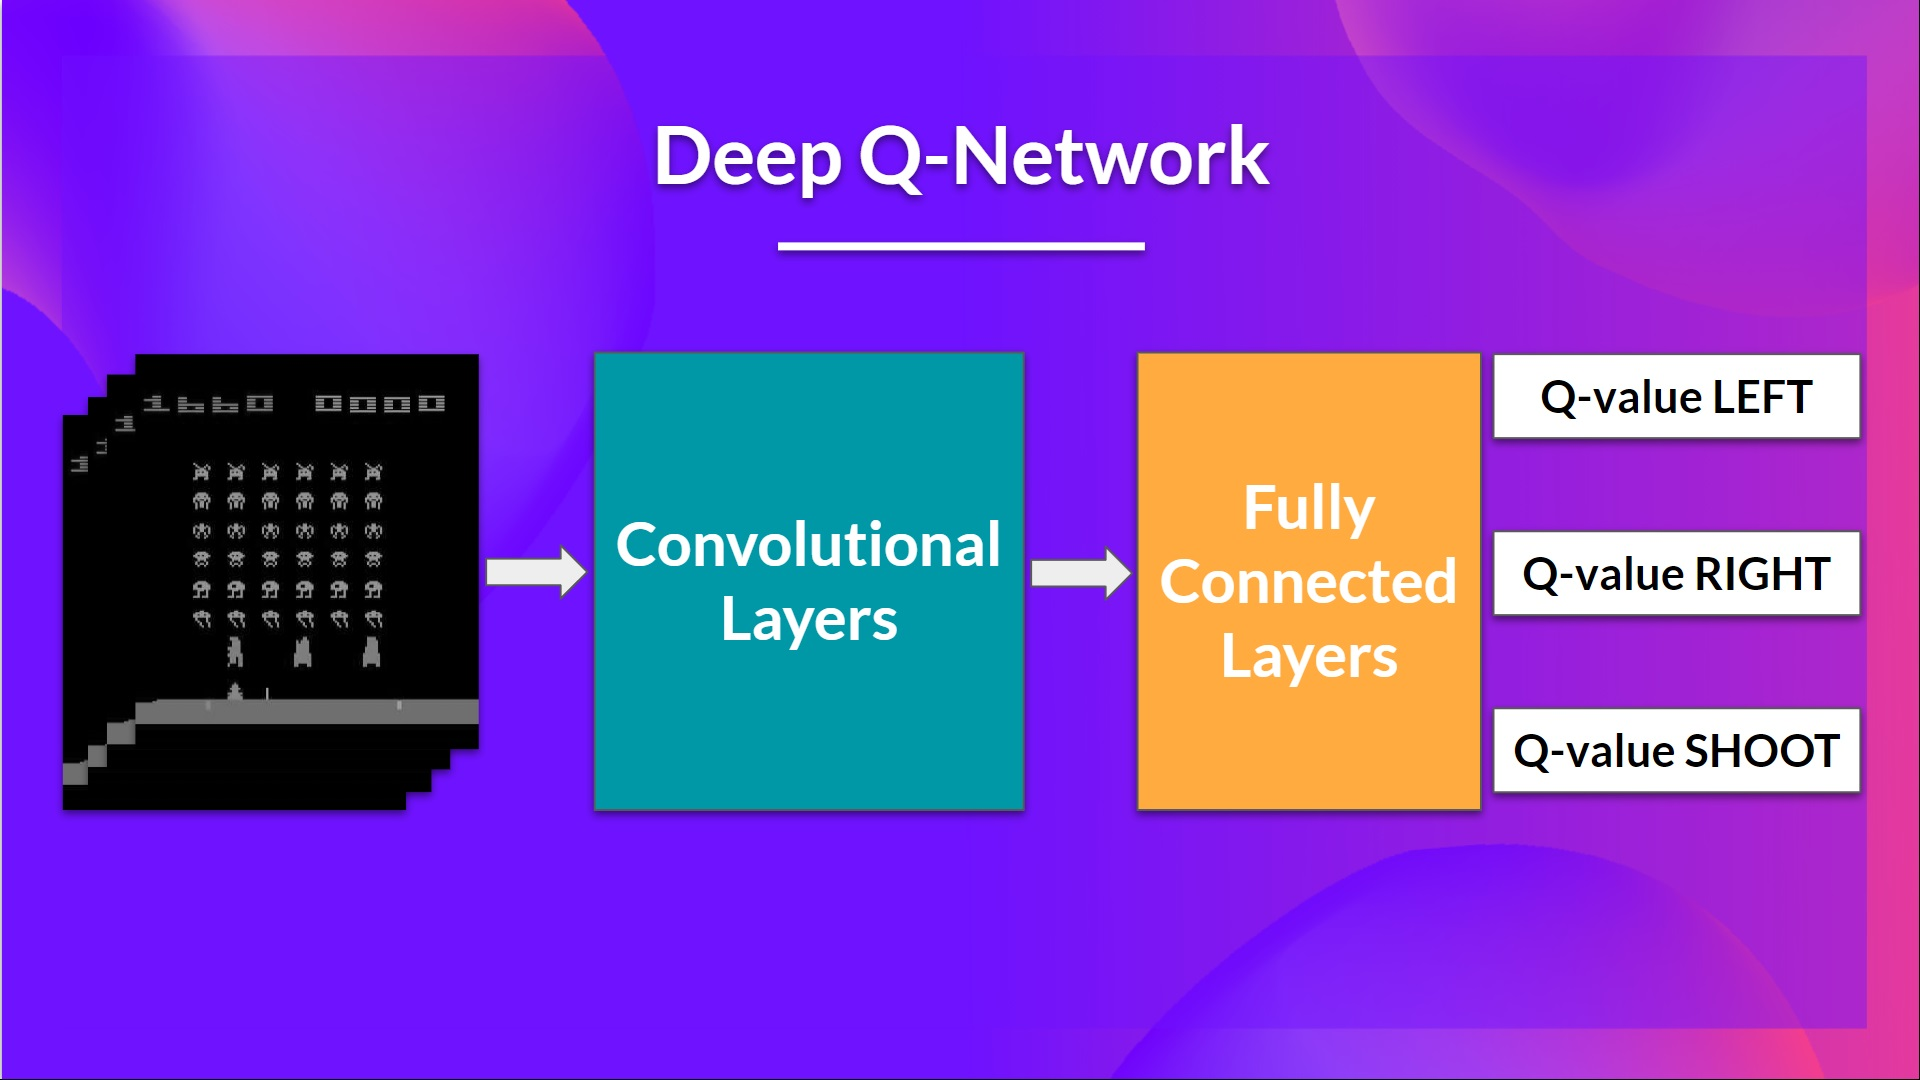

In [10]:
class DQN(nn.Module):
    def __init__(self, input_shape, n_actions):
        super(DQN, self).__init__()
        self.conv1 = nn.Conv2d(input_shape[0], 32, kernel_size=8, stride=4)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, stride=1)

        # calcular el tamaño luego del flatten
        conv_out_size = self.get_conv_out_size(input_shape)

        self.fc1 = nn.Linear(conv_out_size, 512)
        self.fc2 = nn.Linear(512, n_actions)

    def get_conv_out_size(self, shape):
        # Crear input dummy de tamaño (Batch=1, C, H, W)
        # La forma viene como (4, 84, 84, 1) o similar, desde FrameStack
        dummy_input = torch.zeros(1, shape[0], shape[1], shape[2])
        example = self.conv1(dummy_input)
        example = self.conv2(example)
        example = self.conv3(example)
        size = 1
        for x in example.shape:
            size *= x
        return size

    def forward(self, x):
        # x es (Batch, 4, 84, 84, 1) -> convertimos a (Batch, 4, 84, 84)
        if x.dim() == 5:
             x = x.squeeze(-1)

        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Experto

Para "imitation learning" regular es suficiente contar con un dataset de acciones del experto, para clonar su comportamiento (*behaviour cloning*) asumiendo como predicción de la acción correcta la acción del experto para cada estado observado.

Al usar DAGGER, en cambio, consultamos al experto respecto a potenciales situaciones nuevas. Por ello necesitamos involucrar al experto en el loop.
En ambientes reales, este puede ser un humano, pero para efectos de este laboratorio usaremos un modelo pre-entrenado como experto.

## Cargar el modelo experto

In [11]:
!if [ ! -f Expert1.model ]; then wget -O Expert1.model -q https://www.dropbox.com/scl/fi/mmktgv4ajh14546457t4l/Expert1.model?rlkey=lbuij2ow82lsae53588zvneoj&st=7vacfekt&dl=0; fi
!if [ ! -f Expert2.model ]; then wget -O Expert2.model -q https://www.dropbox.com/scl/fi/v33inmb5c8698b1rbymem/Expert2.model?rlkey=b3h3tyvxg410p3nw08sn6v0oh&st=t3tlec8f&dl=0; fi

In [12]:
model_to_use = 'Expert2.model'
if os.path.exists(model_to_use):
    # inicializar el modelo experto con los pesos preentrenados
    expert_state_dict = torch.load(model_to_use, map_location=DEVICE, weights_only=False)
    expert_model = DQN(env.observation_space.shape, env.action_space.n).to(DEVICE)
    expert_model.load_state_dict(expert_state_dict)
else:
    print("WARNING: " + model_to_use + " not found. Upload it to files.")
    expert_model = DQN(env.observation_space.shape, env.action_space.n).to(DEVICE)

## Consultar al experto

In [13]:
def get_action_from_policy(model, states):
    model.eval()
    with torch.no_grad():
        output = model(states)
        _, best_action = torch.max(output, dim=1)
    return best_action

# DAGGER

**Solución:**

<img src="https://miro.medium.com/max/1400/1*RkCKUyRW68fAuysDgWhuMA.png">

In [14]:
# initializamos nuestro modelo "student" con pesos random
student_model = DQN(env.observation_space.shape, env.action_space.n).to(DEVICE)
optimizer = optim.Adam(student_model.parameters())

In [15]:
def evaluate_model(env, model, device, num_episodes=10):
    model.eval()
    rewards = []

    for _ in range(num_episodes):
        state, _ = env.reset()
        total_reward = 0
        done = False

        while not done:
            # Preparar estado
            state_np = np.array([state])
            state_tensor = torch.FloatTensor(state_np).to(device)

            # Obtener acción
            with torch.no_grad():
                action = get_action_from_policy(model, state_tensor).item()

            # Ejecutar acción
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total_reward += reward

        rewards.append(total_reward)

    model.train() # Retornar a training mode, por si se requiere después
    return np.median(rewards)

In [16]:
print("Calculating Expert Baseline Performance (this may take a few minutes)...")
expert_avg_score = evaluate_model(env, expert_model, DEVICE, num_episodes=50)
print(f"Expert Median Score: {expert_avg_score:.2f}")

# Almacenaremos aquí la historia del estudiante, para graficar después
student_history = []
expert_history = [] # Simplemente para graficar la línea horizontal

Calculating Expert Baseline Performance (this may take a few minutes)...
Expert Median Score: 10.00


In [17]:
def train_student_with_eval(student_model, X, Y, optimizer, env, epochs=1):
    # Crear dataset y dataloader
    dataset = torch.utils.data.TensorDataset(X, Y)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)

    student_model.train()

    for epoch in range(epochs):
        running_loss = 0.0
        for i, (states, actions) in enumerate(dataloader):
            states = states.to(DEVICE)
            expert_actions = actions.type(torch.LongTensor).to(DEVICE)

            optimizer.zero_grad()
            student_actions = student_model(states)
            loss = F.cross_entropy(student_actions, expert_actions)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        # Evaluar después de cada época
        avg_val_score = evaluate_model(env, student_model, DEVICE, num_episodes=50)
        student_history.append(avg_val_score)
        expert_history.append(expert_avg_score) # Mantener del mismo largo para el plot

        print(f'[Epoch {epoch + 1}] Loss: {running_loss / (i + 1):.6f} | Student Eval Score: {avg_val_score:.2f}')

In [18]:
# Buffers globales
observations = []
actions = []
num_rollouts = 10000
max_train_samples = 20000

# ---------------------------------------------------------
# FASE 1: Recolectar Data del Experto (Behaviour Cloning)
# ---------------------------------------------------------
print("\n--- Phase 1: Collecting Expert Data ---")
state, _ = env.reset()

with torch.no_grad():
    for _ in range(num_rollouts):
        state_tensor = torch.FloatTensor(np.array([state])).to(DEVICE)
        expert_action = get_action_from_policy(expert_model, state_tensor)
        state, _, terminated, truncated, _ = env.step(expert_action.item())

        observations.append(state_tensor.squeeze(0).cpu())
        actions.append(expert_action.cpu())

        if terminated or truncated: state, _ = env.reset()

print('Num observations:')
observations = observations[-1*max_train_samples:]
actions = actions[-1*max_train_samples:]
print(len(torch.stack(observations)))

print('\nObservation size:')
print(observations[0].shape)

# Entrenar el Student en esos datos
train_student_with_eval(
    student_model,
    torch.stack(observations),
    torch.stack(actions).squeeze(),
    optimizer,
    env,
    epochs=5
)


--- Phase 1: Collecting Expert Data ---
Num observations:
10000

Observation size:
torch.Size([4, 84, 84, 1])
[Epoch 1] Loss: 1.324764 | Student Eval Score: 0.00
[Epoch 2] Loss: 1.286523 | Student Eval Score: 0.00
[Epoch 3] Loss: 1.239310 | Student Eval Score: 0.00
[Epoch 4] Loss: 1.201963 | Student Eval Score: 0.00
[Epoch 5] Loss: 1.167832 | Student Eval Score: 0.00


In [19]:
# ---------------------------------------------------------
# Fases 2-20: Aumentar observaciones con el Student
# ---------------------------------------------------------
for iteration in range(2,20):
    print(f"\n--- Phase {iteration}: Augmenting with Student Data ---")
    state, _ = env.reset()
    with torch.no_grad():
        for _ in range(num_rollouts):
            state_tensor = torch.FloatTensor(np.array([state])).to(DEVICE)

            student_action = get_action_from_policy(student_model, state_tensor)
            expert_action = get_action_from_policy(expert_model, state_tensor)

            state, _, terminated, truncated, _ = env.step(student_action.item())

            observations.append(state_tensor.squeeze(0).cpu())
            actions.append(expert_action.cpu())

            if terminated or truncated: state, _ = env.reset()

    print('Num observations:')
    observations = observations[-1*max_train_samples:]
    actions = actions[-1*max_train_samples:]
    print(len(torch.stack(observations)))

    train_student_with_eval(
        student_model,
        torch.stack(observations),
        torch.stack(actions).squeeze(),
        optimizer,
        env,
        epochs=5
    )


--- Phase 2: Augmenting with Student Data ---
Num observations:
20000
[Epoch 1] Loss: 0.885802 | Student Eval Score: 1.00
[Epoch 2] Loss: 0.654566 | Student Eval Score: 0.00
[Epoch 3] Loss: 0.564352 | Student Eval Score: 0.00
[Epoch 4] Loss: 0.500061 | Student Eval Score: 1.00
[Epoch 5] Loss: 0.437097 | Student Eval Score: 2.00

--- Phase 3: Augmenting with Student Data ---
Num observations:
20000
[Epoch 1] Loss: 0.392601 | Student Eval Score: 2.00
[Epoch 2] Loss: 0.270072 | Student Eval Score: 2.00
[Epoch 3] Loss: 0.206644 | Student Eval Score: 2.00
[Epoch 4] Loss: 0.165374 | Student Eval Score: 2.00
[Epoch 5] Loss: 0.133567 | Student Eval Score: 2.00

--- Phase 4: Augmenting with Student Data ---
Num observations:
20000
[Epoch 1] Loss: 0.591910 | Student Eval Score: 2.00
[Epoch 2] Loss: 0.380576 | Student Eval Score: 2.50
[Epoch 3] Loss: 0.276729 | Student Eval Score: 2.00
[Epoch 4] Loss: 0.210134 | Student Eval Score: 2.00
[Epoch 5] Loss: 0.162030 | Student Eval Score: 2.00

--- Ph

In [20]:
env.close()

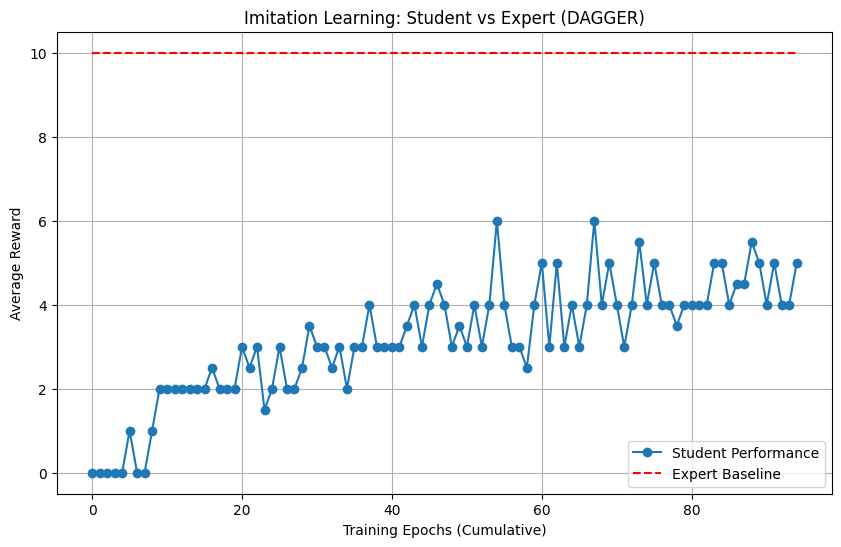

Final Student Average Score: 5.00
Expert Baseline Score: 10.00


In [21]:
# ---------------------------------------------------------
# Gráfico final
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.plot(student_history, label='Student Performance', marker='o', linestyle='-')
plt.plot(expert_history, label='Expert Baseline', linestyle='--', color='red')

plt.title('Imitation Learning: Student vs Expert (DAGGER)')
plt.xlabel('Training Epochs (Cumulative)')
plt.ylabel('Average Reward')
plt.legend()
plt.grid(True)
plt.show()

print(f"Final Student Average Score: {student_history[-1]:.2f}")
print(f"Expert Baseline Score: {expert_avg_score:.2f}")

# Tarea

1. [1.5 puntos] Indica una **ventaja** de usar DAGGER comparado con sólo entrenar imitando al experto (*behaviour cloning*).

2. [1.5 puntos] Indica una **desventaja** de usar DAGGER comparado con sólo entrenar imitando al experto (*behaviour cloning*).

3. [1 punto] ¿Por qué la salida del experto son números reales?

4. [1 punto] ¿Por qué la salida del estudiante son probabilidades?

5. [1 punto] ¿Cómo se maneja la discrepancia entre la salida del experto y el estudiante al usar DAGGER?

# Material complementario: Limitaciones

Aprendizaje por imitación tiene la ventaja de ser más rápido que aprendizaje reforzado., pues la supervisión y exploración es más enfocada en el camino correcto (cada acción es una señal de aprendizaje representativa del estado final al que queremos llegar).

Pero el modelo resultante:
- Está limitado al profesor, en cuanto a rendimiento
- Dificilmente generaliza a situaciones fuera del training set

## Caso de estudio: Starcraft AI SOTA

<img src="https://lh3.googleusercontent.com/ckm-3GlBQJ4zbNzfiW97yPqj5PVC0qIbRg42FL35EbDkhWoCNxyNZMMJN-f6VZmLMRbyBk2PArLQ-jDxlHbsE3_YaDUmcxUvMf8M=w1440">

El Action Space es enorme, y las recompensas son sparse. Por ello se preentrena con immitation learning:

> The neural network was initially trained by supervised learning from anonymised human games released by Blizzard. This allowed AlphaStar to learn, by imitation, the basic micro and macro-strategies used by players on the StarCraft ladder.

Después de este pretraining, se usa aprendizaje reforzado para continuar aprendiendo, permitiendo llegar a rendimientos **sobre-humanos**.

